In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
digits = load_digits()
X = digits.data
y = digits.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model_original = LogisticRegression(max_iter=5000)
model_original.fit(X_train_scaled, y_train)

y_pred_original = model_original.predict(X_test_scaled)
acc_original = accuracy_score(y_test, y_pred_original)

print("Accuracy without PCA:", acc_original)

Accuracy without PCA: 0.9722222222222222


In [ ]:
components = [2, 10, 30, 50]
variance_results = []

for n in components:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    variance_results.append(sum(pca.explained_variance_ratio_))

print("Explained Variance:", variance_results)

Explained Variance: [np.float64(0.217711038132041), np.float64(0.5923315422354275), np.float64(0.8956178801843091), np.float64(0.9833530639634811)]


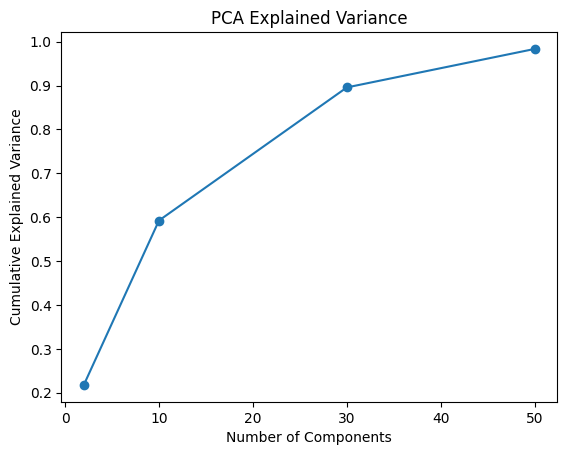

In [ ]:
plt.plot(components, variance_results, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [ ]:
pca = PCA(n_components=30)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model_pca = LogisticRegression(max_iter=5000)
model_pca.fit(X_train_pca, y_train)

y_pred_pca = model_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print("Accuracy with PCA:", acc_pca)

Accuracy with PCA: 0.9611111111111111


In [ ]:
print("\nAccuracy Comparison")
print("Without PCA:", acc_original)
print("With PCA:", acc_pca)


Accuracy Comparison
Without PCA: 0.9722222222222222
With PCA: 0.9611111111111111


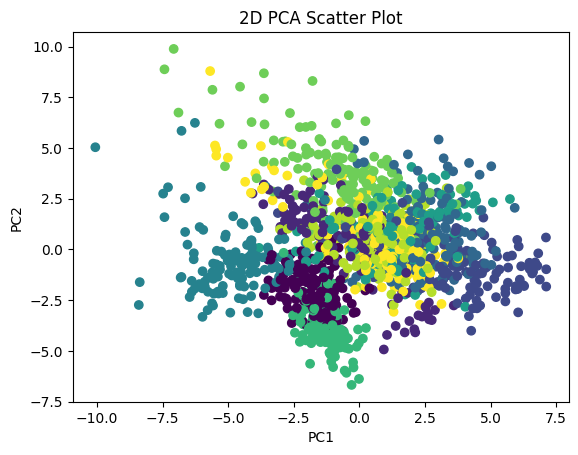

In [ ]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Scatter Plot")
plt.show()